In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('dirty_cafe_sales.csv')
print(df.head())

  Transaction ID    Item Quantity Price Per Unit Total Spent  Payment Method  \
0    TXN_1961373  Coffee        2            2.0         4.0     Credit Card   
1    TXN_4977031    Cake        4            3.0        12.0            Cash   
2    TXN_4271903  Cookie        4            1.0       ERROR     Credit Card   
3    TXN_7034554   Salad        2            5.0        10.0         UNKNOWN   
4    TXN_3160411  Coffee        2            2.0         4.0  Digital Wallet   

   Location Transaction Date  
0  Takeaway       2023-09-08  
1  In-store       2023-05-16  
2  In-store       2023-07-19  
3   UNKNOWN       2023-04-27  
4  In-store       2023-06-11  


In [ ]:
df.isnull()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,True,False,False
9996,False,True,False,True,False,False,True,False
9997,False,False,False,False,False,False,True,False
9998,False,False,False,True,False,False,True,False


In [ ]:
df.isnull().sum()

,0
Transaction ID,0
Item,333
Quantity,138
Price Per Unit,179
Total Spent,173
Payment Method,2579
Location,3265
Transaction Date,159


In [ ]:
#df[df['Item'].isnull()].index for finding index

print("Rows with Null in Item:")
print(df[df['Item'].isnull()]['Item'])

Rows with Null in Item:
8       NaN
30      NaN
61      NaN
72      NaN
89      NaN
       ... 
9820    NaN
9855    NaN
9876    NaN
9885    NaN
9996    NaN
Name: Item, Length: 333, dtype: object


In [ ]:
print(df['Quantity'].dtype)


object


In [ ]:
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')

In [ ]:
print(df['Quantity'].dtype)

float64


(array([3.796e+03, 1.849e+03, 3.875e+03, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00]),
 array([ 1. ,  2.4,  3.8,  5.2,  6.6,  8. ,  9.4, 10.8, 12.2, 13.6, 15. ]),
 <BarContainer object of 10 artists>)

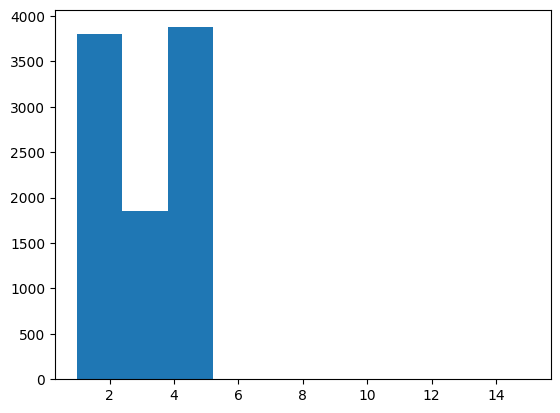

In [ ]:
plt.hist(df['Quantity'])

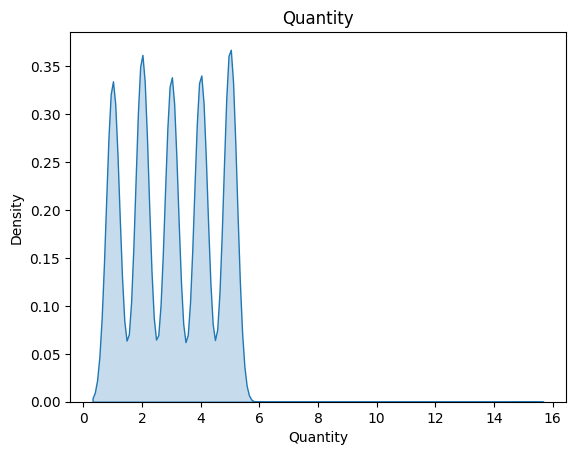

In [ ]:
sns.kdeplot(df['Quantity'], fill=True)
plt.title("Quantity")
plt.show()

In [ ]:
print(df['Price Per Unit'].dtype)

object


In [ ]:
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors = 'coerce')

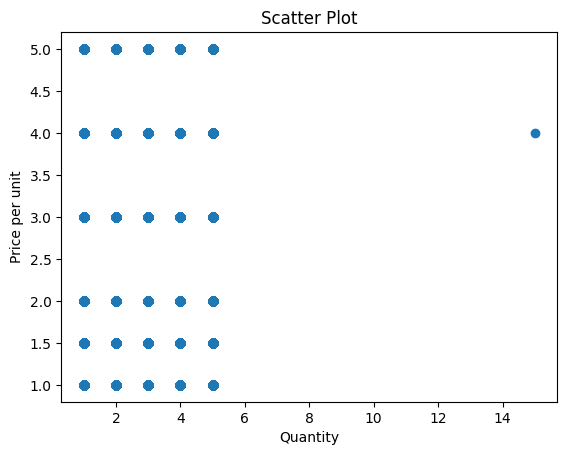

In [ ]:
 x = df['Quantity']
 y = df['Price Per Unit']
 plt.scatter(x,y)
 plt.title("Scatter Plot")
plt.xlabel("Quantity")
plt.ylabel("Price per unit")
plt.show()

In [ ]:
crosstab = pd.crosstab(df['Quantity'], df['Price Per Unit'])
print(crosstab)

Price Per Unit  1.0  1.5  2.0  3.0  4.0  5.0
Quantity                                    
1.0             224  185  227  441  425  233
2.0             235  248  221  490  433  235
3.0             189  214  229  466  453  205
4.0             233  202  223  446  423  234
5.0             208  222  255  489  477  240
15.0              0    0    0    0    1    0


In [ ]:
df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors = 'coerce')

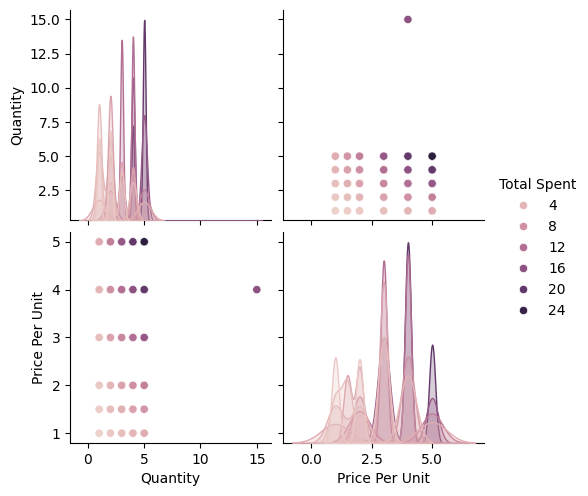

In [ ]:
sns.pairplot(df[["Quantity", "Price Per Unit", "Total Spent"]],
             hue="Total Spent")
plt.show()

In [ ]:
numeric_df = df.select_dtypes(include="number")
corr_matrix = numeric_df.corr()

print(corr_matrix)

                Quantity  Price Per Unit  Total Spent
Quantity        1.000000        0.006758     0.702578
Price Per Unit  0.006758        1.000000     0.647489
Total Spent     0.702578        0.647489     1.000000


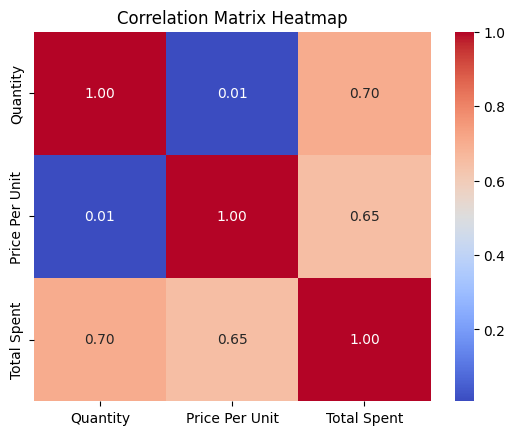

In [ ]:
sns.heatmap(corr_matrix,
            annot=True,        # show numbers
            cmap="coolwarm",   # color scheme
            fmt=".2f")         # 2 decimal places

plt.title("Correlation Matrix Heatmap")
plt.show()

In [ ]:
quantity = df["Quantity"]
print(quantity)

0       2.0
1       4.0
2       4.0
3       2.0
4       2.0
       ... 
9995    2.0
9996    3.0
9997    4.0
9998    3.0
9999    3.0
Name: Quantity, Length: 10000, dtype: float64


In [ ]:
# Remove missing values first
quantity = quantity.dropna()

# Calculate Z-scores

z_scores = (quantity - quantity.mean()) / quantity.std()
# Identify outliers
outliers_z = quantity[(z_scores > 3) | (z_scores < -3)]

print(outliers_z)
print("Number of outliers:", len(outliers_z))

265    15.0
Name: Quantity, dtype: float64
Number of outliers: 1


In [ ]:
Q1 = quantity.quantile(0.25)
Q3 = quantity.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df["Quantity"] < lower_bound) |
                  (df["Quantity"] > upper_bound)]["Quantity"]

print(outliers_iqr)

265    15.0
Name: Quantity, dtype: float64


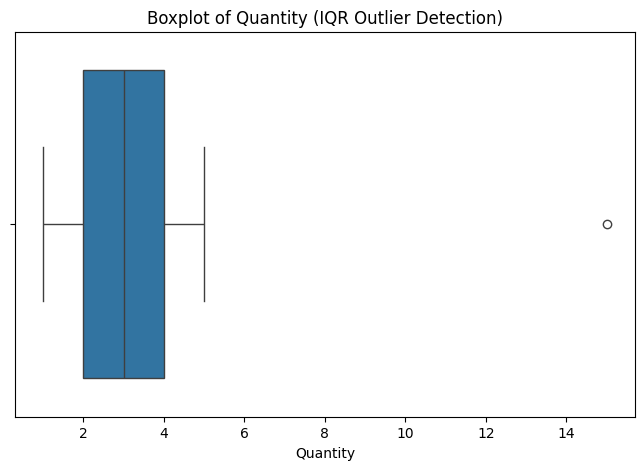

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Quantity"])
plt.title("Boxplot of Quantity (IQR Outlier Detection)")
plt.show()